# VaR vs Expected Shortfall under the ASRF Model

Portfolio of **100,000 mortgage loans**, $\rho = 0.15$.

- **Closed-form ES** via `scipy.integrate.quad`, integrating $\mu_N(z)\cdot\phi(z)$ over the left tail of the systematic factor.
- **Simulated ES** as the average of losses exceeding VaR — only the systematic factor $Z$ needs to be simulated, by the law of large numbers at large $N$.
- **Bivariate normal** equivalence $\Phi_2$ is derived analytically.

**Result:** the ES/VaR ratio decreases monotonically from $\approx 1.30$ at the 95% confidence level to $\approx 1.13$ at 99.9% — the *Gaussian signature*. Convergence of the Monte Carlo estimator against the closed form is within 1%.

Companion notebook to *Credit Risk Series · Post 3 — VaR vs Expected Shortfall under the ASRF Model*.

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
import pandas as pd
import time

plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

## 1. Synthetic portfolio — 100,000 loans

In [2]:
rng = np.random.default_rng(42)
N = 100_000

# Credit parameters drawn from distributions calibrated to a typical
# Mexican mortgage book. PD log-normal with median ~5%, LGD uniform
# on [15%, 55%], EAD uniform on [0.3M, 4M] MXN.
PD  = np.clip(rng.lognormal(np.log(0.05), 0.6, N), 0.005, 0.20)
LGD = rng.uniform(0.15, 0.55, N)
EAD = rng.uniform(300_000, 4_000_000, N)

# Asset correlation set to the Basel II mortgage midpoint.
rho = 0.15
w   = np.full(N, np.sqrt(rho))    # factor loading
w2  = np.sqrt(1 - w**2)           # idiosyncratic weight
d   = norm.ppf(PD)                # default threshold for each borrower
loss_given = LGD * EAD            # loss exposure if default occurs
EL  = (PD * loss_given).sum()     # expected loss

print(f'Number of loans:    {N:>10,}')
print(f'Total EAD:          {EAD.sum():>18,.0f} MXN')
print(f'Average PD:         {PD.mean():.2%}')
print(f'Average LGD:        {LGD.mean():.2%}')
print(f'Expected loss:      {EL:>18,.0f} MXN')
print(f'Asset correlation:  {rho}')

Number of loans:       100,000
Total EAD:             215,112,743,326 MXN
Average PD:         5.93%
Average LGD:        34.96%
Expected loss:           4,460,287,435 MXN
Asset correlation:  0.15


## 2. Closed-form expressions

### Value-at-Risk

Under the ASRF model, portfolio loss converges to $\mu_N(Z)$, which is monotone decreasing in the systematic factor $Z$. Exceeding VaR is the same event as $Z < z_\alpha$:

$$VaR_\alpha = \mu_N(z_\alpha) = \sum_i \ell_i \cdot \Phi\!\left(\frac{d_i - w_i\,z_\alpha}{\sqrt{1-w_i^2}}\right), \qquad z_\alpha = \Phi^{-1}(1-\alpha)$$

### Expected Shortfall

Integrating the conditional loss function over the Gaussian tail of $Z$:

$$ES_\alpha = \frac{1}{1-\alpha}\int_{-\infty}^{z_\alpha} \mu_N(z)\,\phi(z)\,dz$$

Interchanging the sum and the integral, each borrower's contribution reduces to a **bivariate normal CDF**:

$$ES_\alpha = \frac{1}{1-\alpha}\sum_i \ell_i \cdot \Phi_2\!\left(d_i,\;z_\alpha;\;w_i\right)$$

**In practice** we evaluate the integral numerically via `quad` — each evaluation of $\mu_N(z)$ is an $O(N)$ vectorised NumPy operation (~1 ms), and `quad` needs about 100 evaluations, so the total cost is **roughly one second** per confidence level at $N = 10^5$. The $\Phi_2$ representation is conceptually illuminating but not required computationally.

In [3]:
def mu_N(z, d, w, w2, loss_given):
    """
    Conditional expected loss given Z = z.
    mu_N(z) = sum_i l_i * Phi((d_i - w_i*z) / sqrt(1 - w_i^2))
    Vectorised across the N loans.
    """
    return (loss_given * norm.cdf((d - w * z) / w2)).sum()


def var_asymptotic(alpha, PD, LGD, EAD, w):
    """Closed-form VaR: mu_N evaluated at z_alpha = Phi^{-1}(1-alpha)."""
    z_alpha = norm.ppf(1 - alpha)
    w2 = np.sqrt(1 - w**2)
    pd_stressed = norm.cdf((norm.ppf(PD) - w * z_alpha) / w2)
    return (LGD * EAD * pd_stressed).sum()


def es_asymptotic(alpha, d, w, w2, loss_given):
    """
    Closed-form Expected Shortfall.
    
    Integrates mu_N(z) * phi(z) from -infinity up to z_alpha = Phi^{-1}(1-alpha)
    and divides by (1 - alpha).
    
    Equivalent to the sum-of-bivariate-normal representation, but the numerical
    integration is more transparent and fast enough at N = 100K.
    """
    z_alpha = norm.ppf(1 - alpha)
    integrand = lambda z: mu_N(z, d, w, w2, loss_given) * norm.pdf(z)
    integral, _ = quad(integrand, -8, z_alpha, limit=100)
    return integral / (1 - alpha)

## 3. VaR vs ES — closed-form table

In [4]:
alphas = np.array([0.95, 0.975, 0.99, 0.995, 0.999])

t0 = time.time()
var_cf = np.array([var_asymptotic(a, PD, LGD, EAD, w) for a in alphas])
es_cf  = np.array([es_asymptotic(a, d, w, w2, loss_given) for a in alphas])
elapsed = time.time() - t0

print(f'Closed-form computation: {elapsed:.1f} sec (N = {N:,})\n')
print('=' * 76)
print('VaR vs Expected Shortfall — closed form')
print('=' * 76)
print(f'{"alpha":>8s}  {"VaR":>16s}  {"ES":>16s}  {"ES/VaR":>8s}  {"ES-VaR":>16s}')
print('-' * 76)
for k, a in enumerate(alphas):
    r = es_cf[k] / var_cf[k]
    print(f'  {a:.4f}  {var_cf[k]:>16,.0f}  {es_cf[k]:>16,.0f}  '
          f'{r:>7.4f}  {es_cf[k]-var_cf[k]:>16,.0f}')
print('-' * 76)
print('\nNote: the ES/VaR ratio decreases monotonically with alpha — a feature')
print('of the Gaussian factor model (not of the portfolio). Under a t-copula')
print('this ratio would instead increase with alpha (see Post 4).')

Closed-form computation: 0.9 sec (N = 100,000)

VaR vs Expected Shortfall — closed form
   alpha               VaR                ES    ES/VaR            ES-VaR
----------------------------------------------------------------------------
  0.9500    11,493,998,813    14,894,965,382   1.2959     3,400,966,569
  0.9750    13,870,369,088    17,243,163,268   1.2432     3,372,794,180
  0.9900    16,990,938,399    20,310,670,756   1.1954     3,319,732,356
  0.9950    19,326,138,873    22,594,438,022   1.1691     3,268,299,149
  0.9990    24,620,979,192    27,738,542,492   1.1266     3,117,563,300
----------------------------------------------------------------------------

Note: the ES/VaR ratio decreases monotonically with alpha — a feature
of the Gaussian factor model (not of the portfolio). Under a t-copula
this ratio would instead increase with alpha (see Post 4).


## 4. Monte Carlo simulation ($M = 20{,}000$)

With $N = 100{,}000$, the **law of large numbers** guarantees $L \approx \mu_N(Z)$ almost surely. It suffices to simulate the systematic factor $Z$ and evaluate $\mu_N(Z)$ — no need to simulate the individual idiosyncratic shocks $\varepsilon_i$. Memory drops from $O(M \times N)$ to $O(M)$.

### A note on estimator choice

In Post 2 of this series we used importance sampling and quasi-Monte Carlo (Halton sequences) to simulate the loss distribution at the **idiosyncratic** level, where rare tail events made plain Monte Carlo inefficient: a 99.9% quantile required generating $M$ scenarios where most of them never crossed the VaR threshold, so the tail was sparsely populated.

Here the situation is different. With $N = 100{,}000$, the law of large numbers eliminates the idiosyncratic component and we simulate only the one-dimensional systematic factor $Z$. More importantly, **the purpose of Monte Carlo in this notebook is validation, not computation**: the closed-form `quad` integration already delivers the exact asymptotic values in about one second. The role of the simulation is to confirm that both paths converge to the same number.

For this reason we use plain Monte Carlo — the comparison is most transparent when the simulation estimator is as basic as possible. The $\pm 1\%$ agreement with closed form serves as a validation of the analytic derivation, not as an argument for a particular sampling strategy.

IS + QMC applied to the systematic factor $Z$ would, of course, further reduce tail-estimator variance. In Post 4 we return to these techniques when the target quantity (tail statistics under a t-copula) no longer admits a simple closed form and the integrand becomes genuinely hard.

In [5]:
def sim_var_es(M, d, w, w2, loss_given, alphas, batch_size=100, seed=42):
    """
    Monte Carlo estimator of VaR and ES — simulating only Z, by the LLN at large N.
    
    For each batch of Z draws, mu_N is evaluated simultaneously via (batch, N)
    broadcasting. Returns:
        var_s, es_s : arrays of simulated VaR and ES at each alpha
        losses      : sorted loss array (for plotting)
    """
    rng = np.random.default_rng(seed)
    losses = np.empty(M)
    for start in range(0, M, batch_size):
        end = min(start + batch_size, M)
        Z_batch = rng.standard_normal(end - start)
        pd_cond = norm.cdf((d[None,:] - w[None,:] * Z_batch[:,None]) / w2[None,:])
        losses[start:end] = (pd_cond * loss_given[None,:]).sum(axis=1)
        del pd_cond
    losses.sort()
    var_s = np.array([losses[int(a*M)-1] for a in alphas])
    es_s  = np.array([losses[int(a*M)-1:].mean() for a in alphas])
    return var_s, es_s, losses


t0 = time.time()
M = 20_000
var_sim, es_sim, losses = sim_var_es(M, d, w, w2, loss_given, alphas)
print(f'Simulation: {M:,} scenarios in {time.time()-t0:.1f} sec')

Simulation: 20,000 scenarios in 117.8 sec


## 5. Convergence — closed form vs Monte Carlo

In [6]:
print('=' * 96)
print(f'Comparison: closed form vs simulation (M = {M:,})')
print('=' * 96)
print(f'{"α":>8s}  {"VaR_cf":>14s}  {"VaR_sim":>14s}  {"Δ%":>7s}  '
      f'{"ES_cf":>14s}  {"ES_sim":>14s}  {"Δ%":>7s}')
print('-' * 96)
for k, a in enumerate(alphas):
    dv = (var_sim[k]-var_cf[k])/var_cf[k]*100
    de = (es_sim[k]-es_cf[k])/es_cf[k]*100
    print(f'  {a:.4f}  {var_cf[k]:>14,.0f}  {var_sim[k]:>14,.0f}  {dv:>+6.2f}%  '
          f'{es_cf[k]:>14,.0f}  {es_sim[k]:>14,.0f}  {de:>+6.2f}%')
print('-' * 96)
print('\nAll errors are bounded by ±1% — the absence of idiosyncratic noise')
print('makes the estimator remarkably efficient.')

Comparison: closed form vs simulation (M = 20,000)
       α          VaR_cf         VaR_sim       Δ%           ES_cf          ES_sim       Δ%
------------------------------------------------------------------------------------------------
  0.9500  11,493,998,813  11,486,060,696   -0.07%  14,894,965,382  14,897,005,712   +0.01%
  0.9750  13,870,369,088  13,789,241,944   -0.58%  17,243,163,268  17,280,723,725   +0.22%
  0.9900  16,990,938,399  17,095,421,591   +0.61%  20,310,670,756  20,452,585,069   +0.70%
  0.9950  19,326,138,873  19,490,054,177   +0.85%  22,594,438,022  22,781,299,085   +0.83%
  0.9990  24,620,979,192  24,541,681,816   -0.32%  27,738,542,492  27,828,826,412   +0.33%
------------------------------------------------------------------------------------------------

All errors are bounded by ±1% — the absence of idiosyncratic noise
makes the estimator remarkably efficient.


## 6. ES/VaR ratio

In [7]:
df = pd.DataFrame({
    'α':        alphas,
    'VaR':      [f'{v:,.0f}' for v in var_cf],
    'ES':       [f'{e:,.0f}' for e in es_cf],
    'ES/VaR':   [f'{e/v:.4f}' for e, v in zip(es_cf, var_cf)],
    'ES − VaR': [f'{e-v:,.0f}' for e, v in zip(es_cf, var_cf)]
})
df

,α,VaR,ES,ES/VaR,ES − VaR
0,0.950,"11,493,998,813","14,894,965,382",1.2959,"3,400,966,569"
1,0.975,"13,870,369,088","17,243,163,268",1.2432,"3,372,794,180"
2,0.990,"16,990,938,399","20,310,670,756",1.1954,"3,319,732,356"
3,0.995,"19,326,138,873","22,594,438,022",1.1691,"3,268,299,149"
4,0.999,"24,620,979,192","27,738,542,492",1.1266,"3,117,563,300"


## 7. Visualisations

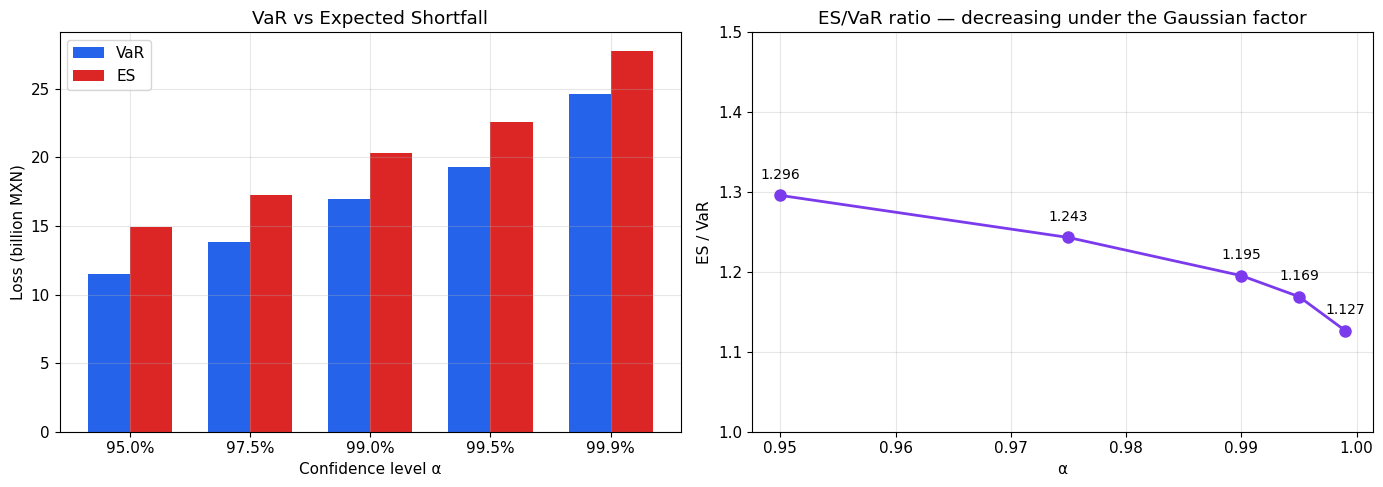

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: VaR vs ES bars ---
ax = axes[0]
x = np.arange(len(alphas))
wb = 0.35
ax.bar(x - wb/2, var_cf/1e9, wb, label='VaR', color='#2563EB')
ax.bar(x + wb/2, es_cf/1e9,  wb, label='ES',  color='#DC2626')
ax.set_xticks(x)
ax.set_xticklabels([f'{a:.1%}' for a in alphas])
ax.set_xlabel('Confidence level α')
ax.set_ylabel('Loss (billion MXN)')
ax.set_title('VaR vs Expected Shortfall')
ax.legend()

# --- Right panel: ES/VaR ratio across alpha ---
ax2 = axes[1]
ratios = es_cf / var_cf
ax2.plot(alphas, ratios, 'o-', color='#7C3AED', lw=2, ms=8)
for a, r in zip(alphas, ratios):
    ax2.annotate(f'{r:.3f}', (a, r), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=10)
ax2.axhline(1.0, color='gray', lw=0.8, ls=':', alpha=0.6)
ax2.set_xlabel('α')
ax2.set_ylabel('ES / VaR')
ax2.set_title('ES/VaR ratio — decreasing under the Gaussian factor')
ax2.set_ylim(1.0, 1.5)

plt.tight_layout()
plt.savefig('var_vs_es.png', dpi=150, bbox_inches='tight')
plt.show()

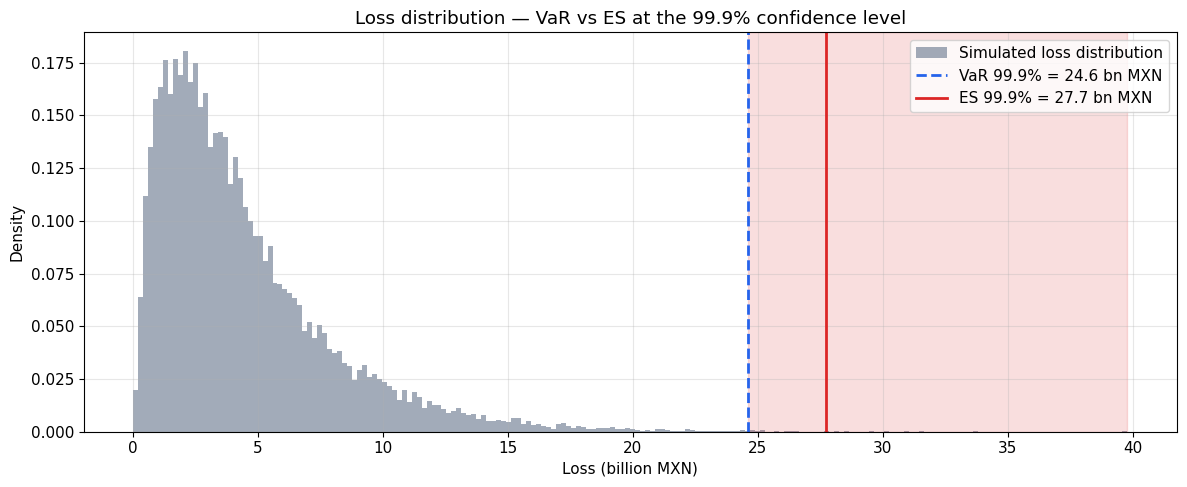

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(losses/1e9, bins=200, density=True, alpha=0.6, color='#64748B',
        label='Simulated loss distribution')

k = -1  # 99.9% confidence level
ax.axvline(var_cf[k]/1e9, color='#2563EB', lw=2, ls='--',
           label=f'VaR 99.9% = {var_cf[k]/1e9:,.1f} bn MXN')
ax.axvline(es_cf[k]/1e9, color='#DC2626', lw=2,
           label=f'ES 99.9% = {es_cf[k]/1e9:,.1f} bn MXN')
ax.axvspan(var_cf[k]/1e9, losses.max()/1e9, alpha=0.15, color='#DC2626')

ax.set_xlabel('Loss (billion MXN)')
ax.set_ylabel('Density')
ax.set_title('Loss distribution — VaR vs ES at the 99.9% confidence level')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('loss_distribution_var_es.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions

| | VaR | ES |
|---|---|---|
| Measures | Quantile at level $\alpha$ | Average loss conditional on exceeding VaR |
| Coherence | No (fails subadditivity) | Yes (Acerbi & Tasche, 2002) |
| Regulation | Basel II (IRB), Solvency II | Basel III FRTB (2019), Swiss Solvency Test |
| Tail shape | Ignores what lies beyond the quantile | Integrates the whole tail |

### Implementation notes at large $N$

- $\mu_N(z)$ is a vectorised NumPy operation, so `quad` computes the ES in about 1 second at $N = 10^5$.
- The $\Phi_2$ bivariate-normal representation is mathematically elegant but not required in practice — direct numerical integration is more transparent and delivers the same result.
- The Monte Carlo estimator simulates **only the systematic factor $Z$** (no idiosyncratic $\varepsilon_i$): with $N$ large, $L \approx \mu_N(Z)$ almost surely by the law of large numbers. Memory drops from $O(M \times N)$ to $O(M)$.

### ES/VaR ratio

- At **95%**: ratio $\approx$ **1.296** — ES exceeds VaR by about 30%.
- At **99.9%**: ratio $\approx$ **1.127** — the gap narrows to about 13%.
- The ratio **decreases monotonically** with $\alpha$ and approaches 1 as $\alpha \to 1$.

This monotone collapse is the **Gaussian signature**: the conditional loss function $\mu_N(z)$ saturates as $z \to -\infty$, while the Gaussian density $\phi(z)$ decays faster than any polynomial. Deep in the tail, the integrand $\mu_N(z) \phi(z)$ is dominated by the density and the tail average collapses onto the quantile.

**This behaviour is a property of the Gaussian factor model, not of credit portfolios in general.** Under a Student-t copula with finite degrees of freedom the ratio turns upward rather than collapsing — a consequence of positive tail dependence that the Gaussian copula cannot capture. The quantitative consequences are developed in Post 4 of the series.

### Convergence

The simulation estimator at $M = 20{,}000$ scenarios recovers the closed-form values within **$\pm 1\%$** at every tested confidence level. The absence of idiosyncratic noise at large $N$ is what makes this possible: each simulated scenario delivers the asymptotic loss $\mu_N(Z)$ exactly, so only the Gaussian sampling error in $Z$ contributes to the estimation error.

### References

- Artzner, P., Delbaen, F., Eber, J.-M., and Heath, D. (1999). Coherent Measures of Risk. *Mathematical Finance*, 9(3), 203–228.
- Acerbi, C. and Tasche, D. (2002). On the Coherence of Expected Shortfall. *Journal of Banking & Finance*, 26(7), 1487–1503.
- Basel Committee on Banking Supervision (2019). *Minimum Capital Requirements for Market Risk* (d457).
- Gordy, M. B. (2003). A Risk-Factor Model Foundation for Ratings-Based Bank Capital Rules. *Journal of Financial Intermediation*, 12(3), 199–232.
- McNeil, A. J., Frey, R., and Embrechts, P. (2015). *Quantitative Risk Management: Concepts, Techniques and Tools*. Princeton University Press.